In [ ]:
# ============= KLASIFIKASI TUTUPAN LAHAN 2020 DAN 2023 =============
# Nama    : Afif Janur
# Data    : Sentinel 2020, Sentinel 2023, dan, Data Training (polygon)
# Metode  : Random forest
# Hasil   : Klasifikasi (Air (1), Vegetasi (2), dan Pemukiman (3))
#         : Akurasi Kappa, Keseluruhan, User, dan Producer
# ============================================================
# 1. INSTALL LIBRARY YANG DIBUTUHKAN
# ============================================================
!pip install rasterio geopandas scikit-learn pandas matplotlib seaborn openpyxl shapely

In [ ]:
# ============================================================
# 2. IMPORT LIBRARY
# ============================================================

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

from rasterio.mask import mask

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    cohen_kappa_score,
    classification_report
)

from google.colab import drive



In [ ]:
# ============================================================
# 3. HUBUNGKAN KE GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 4. MENCARI LOKASI DATA
# ============================================================

DATA_DIR = "/content/drive/MyDrive/Klasifikasi_Tutupan_Lahan"

RASTER_2020 = os.path.join(
    DATA_DIR,
    "Sarbagita_2020.tif"
)

RASTER_2023 = os.path.join(
    DATA_DIR,
    "Sarbagita_2023.tif"
)

TRAINING_SHP = os.path.join(
    DATA_DIR,
    "Data_Training.shp"
)

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "hasil_random_forest"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

In [ ]:
# ============================================================
# 5. NAMA KOLOM KELAS PADA SHAPEFILE
# ============================================================

# GANTI jika nama kolom pada shapefile berbeda
CLASS_FIELD = "kelas"

In [ ]:
#============================================================
# 6. CEK DATA RASTER 2020
# ============================================================

with rasterio.open(RASTER_2020) as src:

    print("==========================================")
    print("SENTINEL-2 2020")
    print("==========================================")

    print("Jumlah band :", src.count)
    print("Ukuran      :", src.width, "x", src.height)
    print("CRS         :", src.crs)
    print("Resolusi    :", src.res)

SENTINEL-2 2020
Jumlah band : 4
Ukuran      : 5075 x 6789
CRS         : EPSG:4326
Resolusi    : (8.983152841195139e-05, 8.983152841195207e-05)


In [ ]:
# ============================================================
# 7. CEK DATA RASTER 2023
# ============================================================

with rasterio.open(RASTER_2023) as src:

    print("\n==========================================")
    print("SENTINEL-2 2023")
    print("==========================================")

    print("Jumlah band :", src.count)
    print("Ukuran      :", src.width, "x", src.height)
    print("CRS         :", src.crs)
    print("Resolusi    :", src.res)


SENTINEL-2 2023
Jumlah band : 4
Ukuran      : 5075 x 6789
CRS         : EPSG:4326
Resolusi    : (8.983152841195139e-05, 8.983152841195207e-05)


In [ ]:
# ============================================================
# 8. BACA TRAINING SHAPEFILE
# ============================================================

training = gpd.read_file(
    TRAINING_SHP
)

print("\n==========================================")
print("DATA TRAINING")
print("==========================================")

print(training.head())

print("\nKolom:")
print(training.columns.tolist())

print("\nJumlah polygon:")
print(len(training))

print("\nDistribusi kelas:")
print(training[CLASS_FIELD].value_counts())


DATA TRAINING
   id kelas                                           geometry
0   1     1  POLYGON ((115.18869 -8.73254, 115.18847 -8.731...
1   2     1  POLYGON ((115.18798 -8.72854, 115.18769 -8.727...
2   3     1  POLYGON ((115.18776 -8.72481, 115.18779 -8.724...
3   4     1  POLYGON ((115.16923 -8.26565, 115.17022 -8.265...
4   5     1  POLYGON ((115.17481 -8.26558, 115.1749 -8.2652...

Kolom:
['id', 'kelas', 'geometry']

Jumlah polygon:
30

Distribusi kelas:
kelas
1    10
2    10
3    10
Name: count, dtype: int64


In [ ]:
# ============================================================
# 9. SAMAKAN CRS TRAINING DENGAN RASTER
# ============================================================

with rasterio.open(RASTER_2020) as src:
    raster_crs = src.crs


if training.crs != raster_crs:

    training = training.to_crs(
        raster_crs
    )


print("\nCRS Training:")
print(training.crs)


CRS Training:
EPSG:4326


NOTE : Data raster dan data shapefile harus mem[punyai sistem koordinat yang sama (overlay) agar data raster dan data shapefile dapat dilakukan pengolahan

  Kelas  Jumlah Pixel
0     1           377
1     2           444
2     3          1158


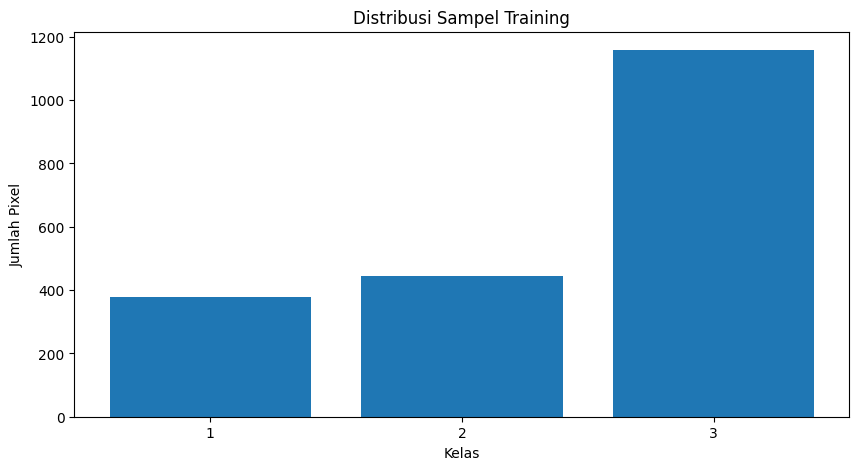

In [ ]:
# ============================================================
# 10. MELIHAT JUMLAH PIKSEL TIAP KELAS
# ============================================================

kelas, jumlah = np.unique(y, return_counts=True)

df_kelas = pd.DataFrame({
    "Kelas": kelas,
    "Jumlah Pixel": jumlah
})

print(df_kelas)

plt.figure(figsize=(10,5))

plt.bar(
    df_kelas["Kelas"].astype(str),
    df_kelas["Jumlah Pixel"]
)

plt.xlabel("Kelas")
plt.ylabel("Jumlah Pixel")
plt.title("Distribusi Sampel Training")

plt.show()

NOTE : Untuk klasifikasai yang digunakan terdiri dari 3 kelas yaitu, kelas air, vegetasi, dan permukiman. Untuk data training yang digunakan haruslah mempunyai jumlah piksel yang hampir sama, agar pembelajaran model lebih optimal. Pada pengolahan ini kelas 3 yaitu pemukiman memang sengaja mempunyai nilai piksel yang lebih banyak dikarenakan bentuk atap yang beragam mulai dari warna putih, orange, kuning, dan cokelat sehingga membutuhkan jumlah piksel yang lebih banyak.

In [ ]:
# ============================================================
# 11. EKSTRAK PIXEL TRAINING DARI SENTINEL-2 2020
# ============================================================

X = []
y = []


with rasterio.open(RASTER_2020) as src:

    for index, row in training.iterrows():

        geometry = [row.geometry]

        # Crop raster berdasarkan polygon training
        out_image, out_transform = mask(
            src,
            geometry,
            crop=True,
            filled=False
        )

        # ----------------------------------------------------
        # Ubah data:
        #
        # band x tinggi x lebar
        #
        # menjadi:
        #
        # pixel x band
        # ----------------------------------------------------

        data = out_image.reshape(
            src.count,
            -1
        ).T


        # Mask pixel yang tidak valid
        mask_array = np.ma.getmaskarray(
            out_image
        )

        invalid = np.any(
            mask_array.reshape(
                src.count,
                -1
            ).T,
            axis=1
        )

        valid = ~invalid

        data = data[valid]


        # Hilangkan NaN
        data = data[
            np.all(
                np.isfinite(data),
                axis=1
            )
        ]


        # Jika terdapat pixel valid
        if len(data) > 0:

            X.append(data)

            # Semua pixel polygon memiliki kelas polygon
            y.extend(
                [row[CLASS_FIELD]] *
                len(data)
            )


# Gabungkan seluruh sampel
X = np.vstack(X)

y = np.array(y)


print("\n==========================================")
print("DATA TRAINING PIXEL")
print("==========================================")

print(
    "Jumlah pixel :",
    X.shape[0]
)

print(
    "Jumlah fitur/band :",
    X.shape[1]
)

print(
    "Jumlah kelas :",
    len(np.unique(y))
)


DATA TRAINING PIXEL
Jumlah pixel : 1979
Jumlah fitur/band : 4
Jumlah kelas : 3


In [ ]:
# ============================================================
# 12. DISTRIBUSI PIXEL PER KELAS
# ============================================================

kelas, jumlah = np.unique(
    y,
    return_counts=True
)

distribusi = pd.DataFrame({

    "Kelas": kelas,

    "Jumlah Pixel": jumlah

})

print("\nDistribusi pixel:")
print(distribusi)



Distribusi pixel:
  Kelas  Jumlah Pixel
0     1           377
1     2           444
2     3          1158


In [ ]:
# ============================================================
# 13. BAGI DATA TRAINING DAN TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=42,

    stratify=y
)


print("\n==========================================")
print("PEMBAGIAN DATA")
print("==========================================")

print(
    "Data training :",
    X_train.shape[0]
)

print(
    "Data testing  :",
    X_test.shape[0]
)



PEMBAGIAN DATA
Data training : 1385
Data testing  : 594


NOTE : Pada klasifikasi ini data dibagi menjadi 2 yaitu data training dan data testing. Data training digunakan untuk mengajari model, sedangkan data testing digunakan unutk menguji model yang dihasilkan. Pada pembagian datanya terdapat 70 % data training dan 30 % data testing.

In [ ]:
# ============================================================
# 14. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(

    n_estimators=300,

    max_features="sqrt",

    random_state=42,

    n_jobs=-1
)


print("\nTraining Random Forest...")

rf.fit(
    X_train,
    y_train
)

print("Training selesai.")


Training Random Forest...
Training selesai.


Metode yang digunakan pada klasifikasi tutupan lahan ini adalah metode Random Forest. Metode RF adalah metode supervised machine learning yang bekerja dengan membuat banyak pohon keputusan (Decision tree), lalu menggabungkan semua pohon itu untuk menghasilkan suatu prediksi. Metode RF sangat cocok digunakan jika terdapat banyak variabel dan data yang overvitting.

In [ ]:
# ============================================================
# 15. PREDIKSI DATA TESTING
# ============================================================

y_pred = rf.predict(
    X_test
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

classes = np.unique(
    y_test
)

cm = confusion_matrix(

    y_test,

    y_pred,

    labels=classes
)


print("\n==========================================")
print("CONFUSION MATRIX")
print("==========================================")

print(cm)



CONFUSION MATRIX
[[113   0   0]
 [  0 132   1]
 [  0   0 348]]


In [ ]:
# ============================================================
# 17. OVERALL ACCURACY
# ============================================================

overall_accuracy = accuracy_score(

    y_test,

    y_pred
)


# ============================================================
# 18. COHEN'S KAPPA
# ============================================================

kappa = cohen_kappa_score(

    y_test,

    y_pred
)


# ============================================================
# 19. PRODUCER ACCURACY
# ============================================================

# Producer Accuracy =
# jumlah pixel benar / jumlah pixel aktual

producer_accuracy = (

    np.diag(cm)

    /

    np.sum(
        cm,
        axis=1
    )
)


# ============================================================
# 20. USER ACCURACY
# ============================================================

# User Accuracy =
# jumlah pixel benar / jumlah pixel hasil klasifikasi

user_accuracy = (

    np.diag(cm)

    /

    np.sum(
        cm,
        axis=0
    )
)

In [ ]:
# ============================================================
# 21. UBAH KE PERSENTASE
# ============================================================

producer_accuracy_percent = (

    producer_accuracy * 100

)


user_accuracy_percent = (

    user_accuracy * 100

)


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

report = classification_report(

    y_test,

    y_pred,

    labels=classes,

    output_dict=True,

    zero_division=0

)


report_df = pd.DataFrame(
    report
).transpose()

In [ ]:
# ============================================================
# 23. TABEL AKURASI PER KELAS
# ============================================================

accuracy_per_class = pd.DataFrame({

    "Kelas": classes,

    "Producer Accuracy (%)":
        np.round(
            producer_accuracy_percent,
            2
        ),

    "User Accuracy (%)":
        np.round(
            user_accuracy_percent,
            2
        )

})


# Ambil precision, recall, F1
class_report = report_df.loc[
    [str(c) for c in classes],
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()


class_report = class_report.reset_index()


class_report.rename(

    columns={

        "index": "Kelas",

        "precision":
            "Precision",

        "recall":
            "Recall",

        "f1-score":
            "F1-Score",

        "support":
            "Jumlah Sampel"

    },

    inplace=True
)


class_report["Kelas"] = classes


# Gabungkan
accuracy_table = class_report.merge(

    accuracy_per_class,

    on="Kelas"

)


In [ ]:
# ============================================================
# 24. HASIL AKURASI
# ============================================================

print("\n==========================================")
print("HASIL UJI AKURASI")
print("==========================================")

print(
    f"Overall Accuracy : "
    f"{overall_accuracy * 100:.2f}%"
)

print(
    f"Cohen's Kappa    : "
    f"{kappa:.4f}"
)

print("\nAkurasi setiap kelas:")

print(
    accuracy_table.round(2)
)


HASIL UJI AKURASI
Overall Accuracy : 99.83%
Cohen's Kappa    : 0.9970

Akurasi setiap kelas:
  Kelas  Precision  Recall  F1-Score  Jumlah Sampel  Producer Accuracy (%)  \
0     1        1.0    1.00       1.0          113.0                 100.00   
1     2        1.0    0.99       1.0          133.0                  99.25   
2     3        1.0    1.00       1.0          348.0                 100.00   

   User Accuracy (%)  
0             100.00  
1             100.00  
2              99.71  


In [ ]:
# ==========================================
# 26. EKPORT UJI AKURASI
# ==========================================

user_accuracy = [100.00, 100.00, 99.71]
producer_accuracy = [100.00, 99.25, 100.00]

# ==========================================
# HITUNG NILAI GABUNGAN
# ==========================================

# Rata-rata User Accuracy
user_mean = sum(user_accuracy) / len(user_accuracy)

# Rata-rata Producer Accuracy
producer_mean = sum(producer_accuracy) / len(producer_accuracy)

# Overall Accuracy
overall_accuracy = 99.83

# Kappa
kappa = 0.9970

# Ubah Kappa menjadi persen
kappa_percent = kappa * 100

# ==========================================
# BUAT TABEL
# ==========================================

hasil = pd.DataFrame({
    "Parameter": [
        "User Accuracy",
        "Producer Accuracy",
        "Overall Accuracy",
        "Cohen's Kappa"
    ],
    "Nilai (%)": [
        round(user_mean, 2),
        round(producer_mean, 2),
        round(overall_accuracy, 2),
        round(kappa_percent, 2)
    ]
})

# ==========================================
# TAMPILKAN
# ==========================================

print(hasil)

# ==========================================
# EXPORT EXCEL
# ==========================================

nama_file = "Hasil_Akurasi_RF.xlsx"

hasil.to_excel(
    nama_file,
    index=False
)

# Download Excel
files.download(nama_file)




           Parameter  Nilai (%)
0      User Accuracy      99.90
1  Producer Accuracy      99.75
2   Overall Accuracy      99.83
3      Cohen's Kappa      99.70


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NOTE : Pada pengolahan ini, model training RF 2020 juga digunakan untuk klasifikasi tutupan lahan 2023 juga. Berdasarkan hasil uji akurasi tersebut, menunjukkan bahwa semua hasil akurasi model yang diuji dengan data testing menghasilkan nilai diatas 90%.

In [ ]:
# ============================================================
# 27. SIMPAN MODEL RANDOM FOREST
# ============================================================

import joblib


model_file = os.path.join(

    OUTPUT_DIR,

    "random_forest_model.pkl"

)


joblib.dump(

    rf,

    model_file

)


print(
    "Model:",
    model_file
)


Model: /content/drive/MyDrive/Klasifikasi_Tutupan_Lahan/hasil_random_forest/random_forest_model.pkl


In [ ]:
# ============================================================
# 28. KLASIFIKASI SENTINEL-2 2020
# ============================================================

with rasterio.open(
    RASTER_2020
) as src:

    image_2020 = src.read()

    profile_2020 = src.profile.copy()

    height_2020 = src.height

    width_2020 = src.width

    bands_2020 = src.count


# Ubah menjadi pixel x band
image_2020_2d = image_2020.reshape(

    bands_2020,

    -1

).T


# Pixel valid
valid_2020 = np.all(

    np.isfinite(
        image_2020_2d
    ),

    axis=1

)


# Prediksi
prediction_2020 = np.zeros(

    image_2020_2d.shape[0],

    dtype=np.int16

)


prediction_2020[
    valid_2020
] = rf.predict(

    image_2020_2d[
        valid_2020
    ]

)


prediction_2020 = prediction_2020.reshape(

    height_2020,

    width_2020

)

In [ ]:
# ============================================================
# 29. EXPORT KLASIFIKASI 2020
# ============================================================

output_2020 = os.path.join(

    OUTPUT_DIR,

    "klasifikasi_random_forest_2020.tif"

)


profile_2020.update(

    dtype=rasterio.int16,

    count=1,

    compress="lzw",

    nodata=0

)


with rasterio.open(

    output_2020,

    "w",

    **profile_2020

) as dst:

    dst.write(

        prediction_2020,

        1

    )


print(
    "Klasifikasi 2020:",
    output_2020
)


Klasifikasi 2020: /content/drive/MyDrive/Klasifikasi_Tutupan_Lahan/hasil_random_forest/klasifikasi_random_forest_2020.tif


In [ ]:
# ============================================================
# 30. KLASIFIKASI SENTINEL-2 2023
# ============================================================

with rasterio.open(
    RASTER_2023
) as src:

    image_2023 = src.read()

    profile_2023 = src.profile.copy()

    height_2023 = src.height

    width_2023 = src.width

    bands_2023 = src.count


# Pastikan jumlah band sama
if bands_2023 != bands_2020:

    raise ValueError(
        "Jumlah band Sentinel-2 2020 dan 2023 berbeda!"
    )


# Pixel x band
image_2023_2d = image_2023.reshape(

    bands_2023,

    -1

).T


# Pixel valid
valid_2023 = np.all(

    np.isfinite(
        image_2023_2d
    ),

    axis=1

)


# Prediksi
prediction_2023 = np.zeros(

    image_2023_2d.shape[0],

    dtype=np.int16

)


prediction_2023[
    valid_2023
] = rf.predict(

    image_2023_2d[
        valid_2023
    ]

)


prediction_2023 = prediction_2023.reshape(

    height_2023,

    width_2023

)


In [ ]:
# ============================================================
# 31. EXPORT KLASIFIKASI 2023
# ============================================================

output_2023 = os.path.join(

    OUTPUT_DIR,

    "klasifikasi_random_forest_2023.tif"

)


profile_2023.update(

    dtype=rasterio.int16,

    count=1,

    compress="lzw",

    nodata=0

)


with rasterio.open(

    output_2023,

    "w",

    **profile_2023

) as dst:

    dst.write(

        prediction_2023,

        1

    )


print(
    "Klasifikasi 2023:",
    output_2023
)



Klasifikasi 2023: /content/drive/MyDrive/Klasifikasi_Tutupan_Lahan/hasil_random_forest/klasifikasi_random_forest_2023.tif


Klasifikasi 2023: /content/drive/MyDrive/Klasifikasi_Tutupan_Lahan/hasil_random_forest/klasifikasi_random_forest_2023.tif


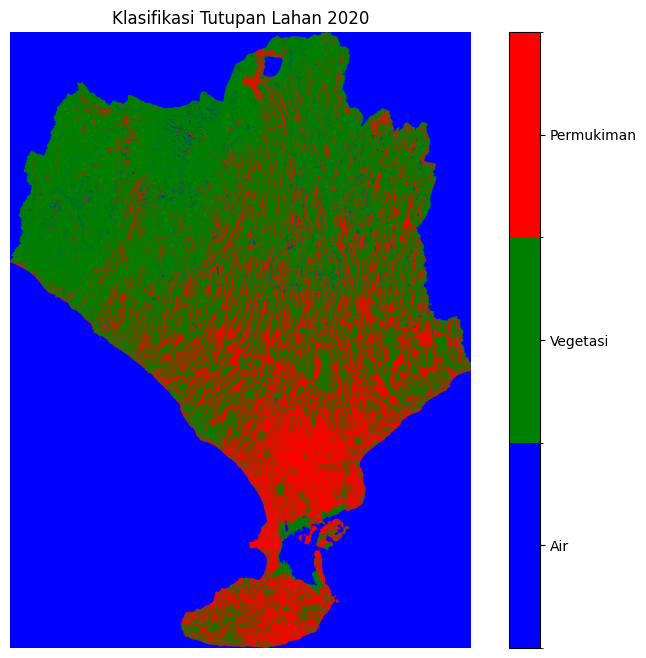

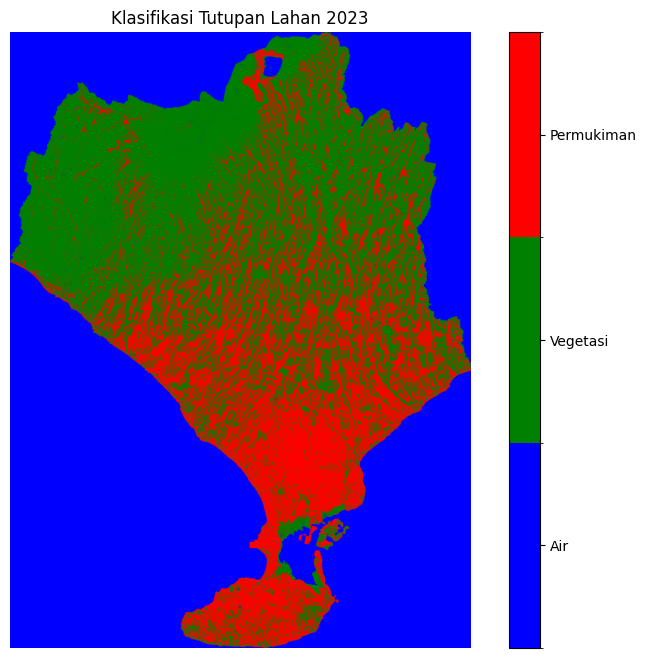

In [ ]:
# ============================================================
# 31. EXPORT KLASIFIKASI 2023
# ============================================================

output_2023 = os.path.join(
    OUTPUT_DIR,
    "klasifikasi_random_forest_2023.tif"
)

profile_2023.update(
    dtype=rasterio.int16,
    count=1,
    compress="lzw",
    nodata=0
)

with rasterio.open(
    output_2023,
    "w",
    **profile_2023
) as dst:

    dst.write(
        prediction_2023.astype(rasterio.int16),
        1
    )

print(
    "Klasifikasi 2023:",
    output_2023
)


# ============================================================
# 32. WARNA KELAS TUTUPAN LAHAN
# ============================================================

from matplotlib.colors import ListedColormap, BoundaryNorm

# Urutan warna sesuai kode kelas
# 1 = Air
# 2 = Vegetasi
# 3 = Permukiman

colors = [
    "blue",
    "green",
    "red"
]

cmap = ListedColormap(colors)

norm = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5],
    cmap.N
)


# ============================================================
# 33. TAMPILKAN KLASIFIKASI 2020
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    prediction_2020,
    cmap=cmap,
    norm=norm
)

plt.title(
    "Klasifikasi Tutupan Lahan 2020"
)

# Colorbar dengan label kelas
cbar = plt.colorbar(
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Air",
    "Vegetasi",
    "Permukiman"
])

plt.axis("off")

plt.show()


# ============================================================
# 34. TAMPILKAN KLASIFIKASI 2023
# ============================================================

plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    prediction_2023,
    cmap=cmap,
    norm=norm
)

plt.title(
    "Klasifikasi Tutupan Lahan 2023"
)

# Colorbar dengan label kelas
cbar = plt.colorbar(
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Air",
    "Vegetasi",
    "Permukiman"
])

plt.axis("off")

plt.show()
